# Vulnerabilidade Socioambiental em Belo Horizonte
## Análise exploratória por setores censitários — Censo 2022 (IBGE)

**Objetivo:** Mapear a distribuição espacial da vulnerabilidade socioambiental em Belo Horizonte, utilizando indicadores de acesso a água, esgoto, coleta de lixo e condições sanitárias a partir dos dados do Censo Demográfico 2022.

**Metodologia:** Foi construído um índice composto de vulnerabilidade a partir de 4 indicadores por setor censitário:
- % de domicílios sem rede geral de água
- % de domicílios sem rede de esgoto
- % de domicílios sem coleta de lixo
- % de domicílios sem banheiro

O índice final é a média simples dos 4 indicadores (0 = nenhuma vulnerabilidade, 1 = vulnerabilidade máxima).

**Fontes:** IBGE — Agregados por Setores Censitários (Censo 2022); Malha de Setores Censitários 2022.

**Ferramentas:** Python, GeoPandas, Matplotlib, Mapclassify.

In [22]:
#instalando as bibliotecas
!pip install geopandas mapclassify folium -q

In [23]:
#importando as bibliotecas
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import os
import requests
from io import BytesIO

print("tudo importado com sucesso!")

tudo importado com sucesso!


In [24]:
#carregando shapefile e filtrar BH
gdf = gpd.read_file("MG_setores_CD2022.shp")
print(f"Total de setores em MG: {len(gdf)}")
print(f"Colunas: {list(gdf.columns)}")
print(gdf.head())

Total de setores em MG: 51387
Colunas: ['CD_SETOR', 'SITUACAO', 'CD_SIT', 'CD_TIPO', 'AREA_KM2', 'CD_REGIAO', 'NM_REGIAO', 'CD_UF', 'NM_UF', 'CD_MUN', 'NM_MUN', 'CD_DIST', 'NM_DIST', 'CD_SUBDIST', 'NM_SUBDIST', 'CD_BAIRRO', 'NM_BAIRRO', 'CD_NU', 'NM_NU', 'CD_FCU', 'NM_FCU', 'CD_AGLOM', 'NM_AGLOM', 'CD_RGINT', 'NM_RGINT', 'CD_RGI', 'NM_RGI', 'CD_CONCURB', 'NM_CONCURB', 'geometry']
          CD_SETOR SITUACAO CD_SIT CD_TIPO  AREA_KM2 CD_REGIAO NM_REGIAO  \
0  310010405000001   Urbana      1       0  0.270934         3   Sudeste   
1  310010405000002   Urbana      1       0  0.176252         3   Sudeste   
2  310010405000003   Urbana      1       0  0.138859         3   Sudeste   
3  310010405000004   Urbana      1       0  0.224741         3   Sudeste   
4  310010405000005   Urbana      1       0  0.111173         3   Sudeste   

  CD_UF         NM_UF   CD_MUN  ... NM_FCU CD_AGLOM NM_AGLOM CD_RGINT  \
0    31  Minas Gerais  3100104  ...   None     None     None     3111   
1    31  Minas

Setores censitários em BH: 5166


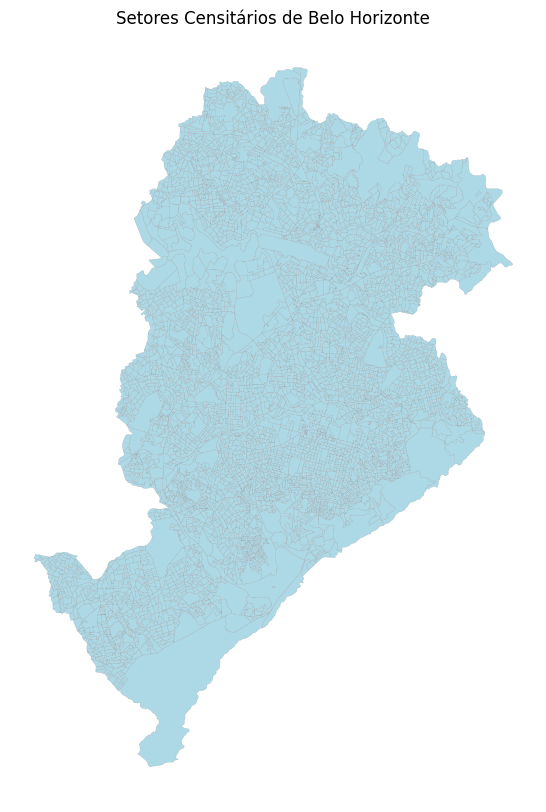

In [25]:
#filtrando apenas belo horizonte
bh = gdf[gdf["NM_MUN"] == "Belo Horizonte"].copy()
print(f"Setores censitários em BH: {len(bh)}")

#visualização rápida
bh.plot(figsize=(10,10), edgecolor="gray", linewidth=0.1, color="lightblue")
plt.title("Setores Censitários de Belo Horizonte")
plt.axis("off")
plt.show()

In [45]:
#listando os novos arquivos do censo 2022
import glob
csvs = glob.glob("*.csv")
xlsxs = glob.glob("*.xlsx")
print("CSVs:", csvs)
print("XLSX:", xlsxs)

CSVs: ['Agregados_por_setores_caracteristicas_domicilio3_BR_20250417.csv', 'Agregados_por_setores_caracteristicas_domicilio1_BR.csv', 'Agregados_por_setores_caracteristicas_domicilio2_BR_20250417.csv']
XLSX: ['dicionario_de_dados_agregados_por_setores_censitarios_20250417.xlsx']


In [46]:
#checar as colunas dos csvs
for csv in csvs:
    df = pd.read_csv(csv, nrows=2, sep=";", encoding="latin1")
    print(f"\n {csv}")
    print(f"Colunas ({len(df.columns)}): {list(df.columns)[:20]}")
    if len(df.columns) > 20:
        print(f"... e mais {len(df.columns)-20} colunas")


 Agregados_por_setores_caracteristicas_domicilio3_BR_20250417.csv
Colunas (149): ['setor', 'V00496', 'V00497', 'V00498', 'V00499', 'V00500', 'V00501', 'V00502', 'V00503', 'V00504', 'V00505', 'V00506', 'V00507', 'V00508', 'V00509', 'V00510', 'V00511', 'V00512', 'V00513', 'V00514']
... e mais 129 colunas

 Agregados_por_setores_caracteristicas_domicilio1_BR.csv
Colunas (90): ['CD_setor', 'V00001', 'V00002', 'V00003', 'V00004', 'V00005', 'V00006', 'V00007', 'V00008', 'V00009', 'V00010', 'V00011', 'V00012', 'V00013', 'V00014', 'V00015', 'V00016', 'V00017', 'V00018', 'V00019']
... e mais 70 colunas

 Agregados_por_setores_caracteristicas_domicilio2_BR_20250417.csv
Colunas (407): ['setor', 'V00090', 'V00091', 'V00092', 'V00093', 'V00094', 'V00095', 'V00096', 'V00097', 'V00098', 'V00099', 'V00100', 'V00101', 'V00102', 'V00103', 'V00104', 'V00105', 'V00106', 'V00107', 'V00108']
... e mais 387 colunas


In [47]:
#lendo dicionário de dados
dicionario = pd.read_excel("dicionario_de_dados_agregados_por_setores_censitarios_20250417.xlsx", sheet_name=None)

for sheet, df in dicionario.items():
    print(f"\n ABA: {sheet}")
    print(df.head(10).to_string())


 ABA: Dicionário Básico
     Tema Variável                                                                                                                 Descrição
0  Básico    V0001                                                                                                          Total de pessoas
1  Básico    V0002                                                            Total de Domicílios (DPPO + DPPV + DPPUO + DPIO + DCCM + DCSM)
2  Básico    V0003                                                             Total de Domicílios Particulares (DPPO + DPPV + DPPUO + DPIO)
3  Básico    V0004                                                                               Total de Domicílios Coletivos (DCCM + DCSM)
4  Básico    V0005  Média de moradores em Domicílios Particulares Ocupados (Total pessoas em Domicílios Particulares Ocupados / DPPO + DPIO)
5  Básico    V0006                                Percentual de Domicílios Particulares Ocupados Imputados (Total DPO imputados /

In [48]:
#filtrando variáveis de domicílio (saneamento)
dic = dicionario["Dicionário não PCT"]
#mostrando variáveis que mencionam água, esgoto, lixo, banheiro
filtro = dic[dic["Descrição"].str.contains("água|esgoto|lixo|banheiro|sanitário|rede geral|fossa|céu aberto", case=False, na=False)]
print(filtro[["Variável","Descrição"]].to_string())

    Variável                                                                                                                                                                                                                           Descrição
110   V00111                                                                                                                                                    Domicílios Particulares Permanentes Ocupados, Utiliza rede geral de distribuição
115   V00116                                                                                                                                                      Domicílios Particulares Permanentes Ocupados, Utiliza água da chuva armazenada
117   V00118                                                                                                                                          Domicílios Particulares Permanentes Ocupados, Utiliza outra forma de abastecimento de água
118   V00119                        

V00001: Total domicílios permanentes ocupados

V00111: Usa rede geral de água

V00309: Esgoto rede geral/pluvial

V00238: Sem banheiro nem sanitário

V00397: Lixo coletado por serviço de limpeza

V00401: Lixo jogado em terreno baldio

In [49]:
import csv

# dom1: engine python funciona melhor aqui
dom1 = pd.read_csv("Agregados_por_setores_caracteristicas_domicilio1_BR.csv",
                    sep=";", encoding="latin1", engine="python", on_bad_lines="skip")
print(f"dom1: {len(dom1)} linhas")
dom1.columns = dom1.columns.str.replace('"', '')
dom1 = dom1.loc[:, ~dom1.columns.duplicated()]
col_setor1 = dom1.columns[0]
dom1 = dom1.rename(columns={col_setor1: "setor"})
dom1["setor"] = dom1["setor"].astype(str).str.replace('"', '')
dom1_bh = dom1[dom1["setor"].str[:7] == "3106200"].copy()
print(f"dom1 BH: {len(dom1_bh)}")

# dom2: QUOTE_NONE sem skip funciona melhor
dom2 = pd.read_csv("Agregados_por_setores_caracteristicas_domicilio2_BR_20250417.csv",
                    sep=";", encoding="latin1", quoting=csv.QUOTE_NONE)
print(f"\ndom2: {len(dom2)} linhas")
dom2.columns = dom2.columns.str.replace('"', '')
dom2 = dom2.loc[:, ~dom2.columns.duplicated()]
dom2["setor"] = dom2["setor"].astype(str).str.replace('"', '')
dom2_bh = dom2[dom2["setor"].str[:7] == "3106200"].copy()
print(f"dom2 BH: {len(dom2_bh)}")

# Juntar
dom_bh = dom1_bh[["setor", "V00001"]].merge(
    dom2_bh[["setor", "V00111", "V00309", "V00238", "V00397", "V00401"]],
    on="setor", how="inner")
print(f"\nSetores com dados completos: {len(dom_bh)}")

# Converter para numérico
for c in ["V00001", "V00111", "V00309", "V00238", "V00397", "V00401"]:
    dom_bh[c] = pd.to_numeric(dom_bh[c].astype(str).str.replace('"', ''), errors="coerce").fillna(0)

# Indicadores
dom_bh["pct_sem_rede_agua"] = 1 - (dom_bh["V00111"] / dom_bh["V00001"].replace(0, np.nan))
dom_bh["pct_sem_rede_esgoto"] = 1 - (dom_bh["V00309"] / dom_bh["V00001"].replace(0, np.nan))
dom_bh["pct_sem_coleta_lixo"] = 1 - (dom_bh["V00397"] / dom_bh["V00001"].replace(0, np.nan))
dom_bh["pct_sem_banheiro"] = dom_bh["V00238"] / dom_bh["V00001"].replace(0, np.nan)

dom_bh["vulnerabilidade"] = dom_bh[["pct_sem_rede_agua", "pct_sem_rede_esgoto",
                                     "pct_sem_coleta_lixo", "pct_sem_banheiro"]].mean(axis=1)

# Merge com malha
dom_bh = dom_bh.rename(columns={"setor": "CD_SETOR"})
bh["CD_SETOR"] = bh["CD_SETOR"].astype(str)
bh_vuln = bh.merge(dom_bh[["CD_SETOR", "pct_sem_rede_agua", "pct_sem_rede_esgoto",
                            "pct_sem_coleta_lixo", "pct_sem_banheiro", "vulnerabilidade"]],
                   on="CD_SETOR", how="left")

print(f"\nSetores com índice: {bh_vuln['vulnerabilidade'].notna().sum()} de {len(bh_vuln)}")
print(bh_vuln["vulnerabilidade"].describe())

dom1: 458772 linhas
dom1 BH: 5137

dom2: 243658 linhas
dom2 BH: 5137

Setores com dados completos: 5137

Setores com índice: 5113 de 5166
count    5113.000000
mean        0.021397
std         0.070306
min         0.000000
25%         0.000000
50%         0.001225
75%         0.005882
max         0.750000
Name: vulnerabilidade, dtype: float64


In [50]:
#estatística descritivas dos indicadores
resumo = bh_vuln[["pct_sem_rede_agua","pct_sem_rede_esgoto",
                   "pct_sem_coleta_lixo","pct_sem_banheiro","vulnerabilidade"]].describe()
resumo.index = ["Contagem","Média","Desvio Padrão","Mínimo","25%","Mediana","75%","Máximo"]
resumo.columns = ["Sem Água","Sem Esgoto","Sem Coleta Lixo","Sem Banheiro","Vulnerabilidade"]

#formatar como percentual
print("ESTATÍSTICAS DESCRITIVAS DOS INDICADORES (em proporção)")
print(resumo.round(4).to_string())

#top 10 setores mais vulneráveis
print("\n")
print("TOP 10 SETORES MAIS VULNERÁVEIS")
top10 = bh_vuln.nlargest(10, "vulnerabilidade")[["CD_SETOR","NM_BAIRRO","vulnerabilidade",
        "pct_sem_rede_agua","pct_sem_rede_esgoto","pct_sem_coleta_lixo","pct_sem_banheiro"]]
print(top10.to_string(index=False))

ESTATÍSTICAS DESCRITIVAS DOS INDICADORES (em proporção)
                Sem Água  Sem Esgoto  Sem Coleta Lixo  Sem Banheiro  Vulnerabilidade
Contagem       5113.0000   5113.0000        5113.0000        5113.0        5113.0000
Média             0.0083      0.0351           0.0422           0.0           0.0214
Desvio Padrão     0.0615      0.1380           0.1537           0.0           0.0703
Mínimo            0.0000      0.0000           0.0000           0.0           0.0000
25%               0.0000      0.0000           0.0000           0.0           0.0000
Mediana           0.0000      0.0000           0.0000           0.0           0.0012
75%               0.0000      0.0064           0.0065           0.0           0.0059
Máximo            1.0000      1.0000           1.0000           0.0           0.7500


TOP 10 SETORES MAIS VULNERÁVEIS
       CD_SETOR                     NM_BAIRRO  vulnerabilidade  pct_sem_rede_agua  pct_sem_rede_esgoto  pct_sem_coleta_lixo  pct_sem_banheiro
310

## Resultados: Mapas de Vulnerabilidade

Os mapas abaixo classificam os setores censitários usando o método Natural Breaks (Jenks), que identifica agrupamentos naturais nos dados. Os setores sem nenhum déficit (valor = 0%) são destacados separadamente, permitindo visualizar com clareza onde a precariedade de infraestrutura se concentra.

/tmp/ipykernel_10931/475883300.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap(cmap)


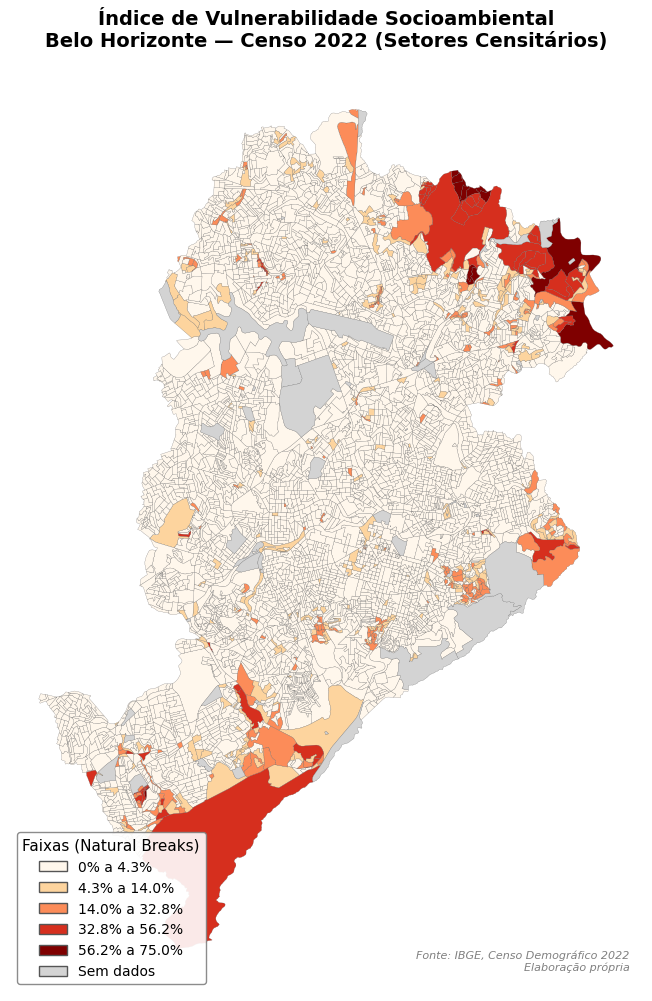

Salvo: mapa_vulnerabilidade_bh.png
Faixas: [np.float64(4.3), np.float64(14.0), np.float64(32.8), np.float64(56.2), np.float64(75.0)]%



/tmp/ipykernel_10931/475883300.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap(cmap)


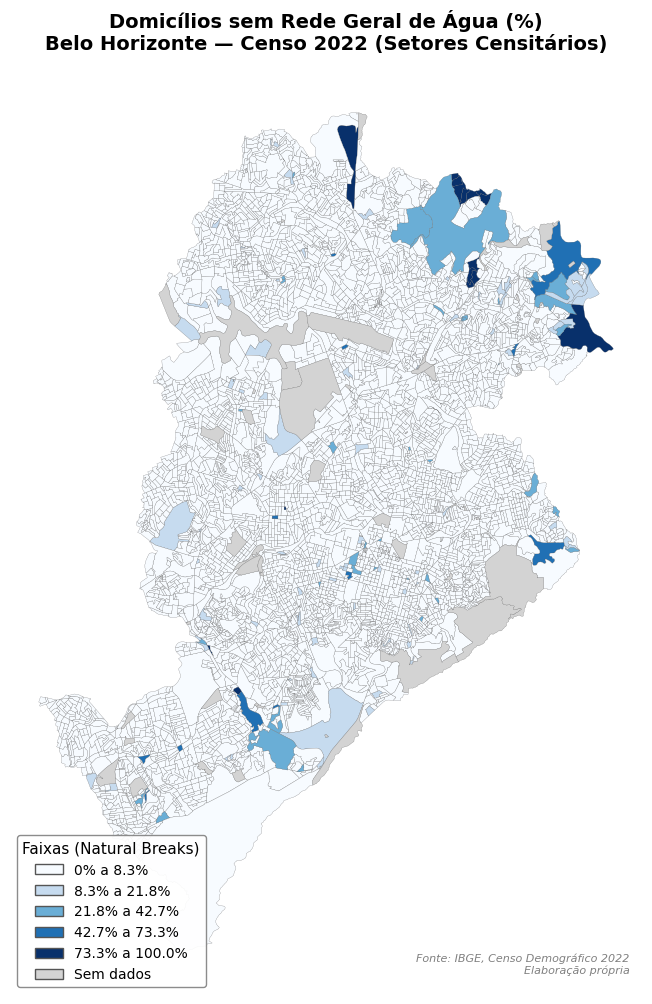

Salvo: mapa_pct_sem_rede_agua_bh.png
Faixas: [np.float64(8.3), np.float64(21.8), np.float64(42.7), np.float64(73.3), np.float64(100.0)]%



/tmp/ipykernel_10931/475883300.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap(cmap)


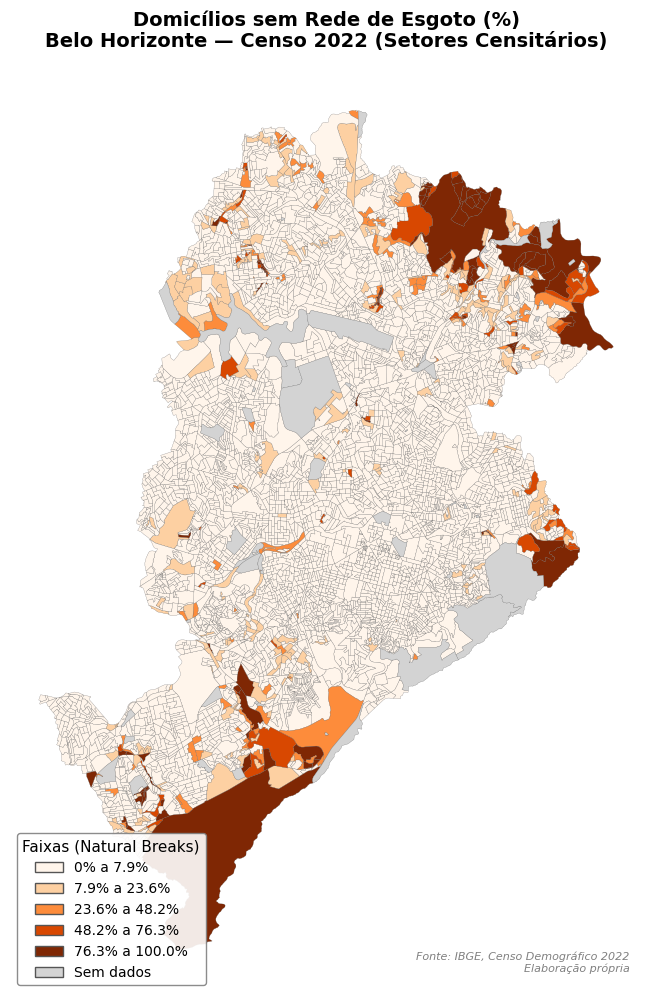

Salvo: mapa_pct_sem_rede_esgoto_bh.png
Faixas: [np.float64(7.9), np.float64(23.6), np.float64(48.2), np.float64(76.3), np.float64(100.0)]%



/tmp/ipykernel_10931/475883300.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap(cmap)


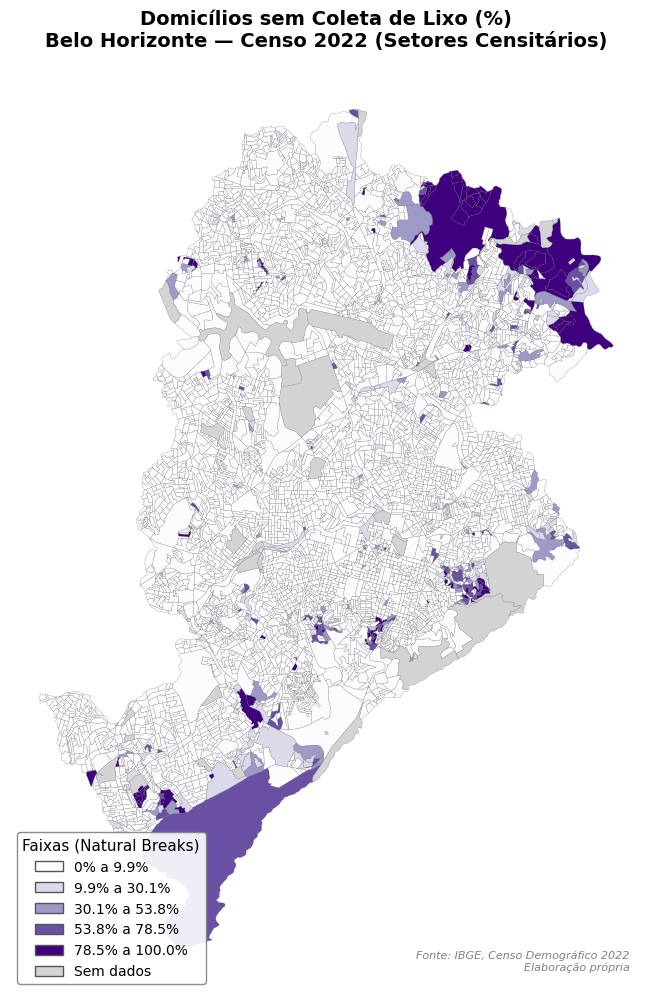

Salvo: mapa_pct_sem_coleta_lixo_bh.png
Faixas: [np.float64(9.9), np.float64(30.1), np.float64(53.8), np.float64(78.5), np.float64(100.0)]%



In [53]:
#mapas com natural breaks (jenks)
import matplotlib.patches as mpatches
from mapclassify import NaturalBreaks

mapas = [
    ("vulnerabilidade", "OrRd", "Índice de Vulnerabilidade Socioambiental"),
    ("pct_sem_rede_agua", "Blues", "Domicílios sem Rede Geral de Água (%)"),
    ("pct_sem_rede_esgoto", "Oranges", "Domicílios sem Rede de Esgoto (%)"),
    ("pct_sem_coleta_lixo", "Purples", "Domicílios sem Coleta de Lixo (%)"),
]

for col, cmap, titulo in mapas:
    fig, ax = plt.subplots(1, 1, figsize=(10, 12))

    dados = bh_vuln[col].dropna()
    dados_pos = dados[dados > 0]

    nb = NaturalBreaks(dados_pos, k=5)
    bins = nb.bins

    bh_vuln.plot(column=col, cmap=cmap, scheme="natural_breaks", k=5,
                 ax=ax, edgecolor="#555555", linewidth=0.15,
                 missing_kwds={"color": "lightgray", "edgecolor": "#555555"}, legend=False)

    # Legenda
    labels = [f"0% a {bins[0]*100:.1f}%"]
    for i in range(1, len(bins)):
        labels.append(f"{bins[i-1]*100:.1f}% a {bins[i]*100:.1f}%")
    labels.append("Sem dados")

    cm = plt.cm.get_cmap(cmap)
    cores = [cm(i/(len(bins)-1)) for i in range(len(bins))] + [(0.83, 0.83, 0.83, 1)]
    patches = [mpatches.Patch(facecolor=c, edgecolor="#555555", label=l)
               for c, l in zip(cores, labels)]

    ax.legend(handles=patches, loc="lower left", fontsize=10,
              title="Faixas (Natural Breaks)", title_fontsize=11,
              framealpha=0.9, edgecolor="gray")

    ax.set_title(titulo + "\nBelo Horizonte — Censo 2022 (Setores Censitários)",
                 fontsize=14, fontweight="bold", pad=15)
    ax.axis("off")
    ax.text(0.98, 0.02, "Fonte: IBGE, Censo Demográfico 2022\nElaboração própria",
            transform=ax.transAxes, fontsize=8, ha="right", va="bottom",
            style="italic", color="gray")

    nome = f"mapa_{col}_bh.png"
    plt.savefig(nome, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Salvo: {nome}")
    print(f"Faixas: {[round(b*100,1) for b in bins]}%\n")

## Considerações Finais

A análise revela um padrão claro de desigualdade intraurbana em Belo Horizonte. As áreas de maior vulnerabilidade socioambiental concentram-se nas periferias norte e sul do município, onde os déficits de infraestrutura de saneamento são mais acentuados.

Os resultados são consistentes com o que a literatura sobre urbanização periférica no Brasil aponta: a expansão urbana em áreas não planejadas gera territórios com acesso precário a serviços básicos, reforçando ciclos de exclusão socioespacial.

Esses dados são relevantes para a formulação de políticas públicas que visam a urbanização e melhoria das condições de vida em territórios periféricos.

---
*Análise realizada com dados públicos do IBGE (Censo 2022). Código disponível neste repositório.*